# CardioIA — Ir Além 2: diagnóstico visual de ECG com MLP em Keras

**Grupo Zion** — FIAP, curso de Inteligência Artificial (PBL). Entrega extra da Fase 2 (não faz parte da atividade principal). Redação e código preparados com apoio de assistente de IA (Claude Code) e revisados pelo grupo.

> ⚠️ **Simulação acadêmica, sem validade clínica.** Nada neste notebook serve para triagem, diagnóstico ou decisão médica real.

Este notebook treina uma **rede neural MLP (Multilayer Perceptron) em Keras** para classificar imagens de eletrocardiograma em **normal** ou **anormal**, depois de pré-processá-las (recorte, tons de cinza, redimensionamento, normalização).

**Dataset.** *ECG Images dataset of Cardiac Patients*, versão 2, Mendeley Data, DOI [10.17632/gwbz3fsgp8.2](https://doi.org/10.17632/gwbz3fsgp8.2), licença **CC BY 4.0** — a mesma base de imagens da Fase 1 deste projeto. Usamos esta base **no lugar** do `shayanfazeli/heartbeat` do Kaggle recomendado no enunciado porque aquele dataset é de **sinais segmentados em CSV**, não de imagens: não há o que redimensionar nem converter para tons de cinza. As imagens do Mendeley cumprem o texto do enunciado e reaproveitam a auditoria de duplicatas da Fase 1.

Tudo o que é testado aqui foi **pré-registrado antes de qualquer treino** em [`document/fase-02/ir-alem-2/protocolo-mlp.md`](../../../document/fase-02/ir-alem-2/protocolo-mlp.md), commitado sozinho, antes deste notebook.

## 1. Setup

Detecta se está rodando no Google Colab ou localmente. No Colab, clona o repositório (para ter o manifest e o script de download); localmente, usa o próprio repositório. Fixa a semente e liga o determinismo de operações do TensorFlow.

In [1]:
import hashlib
import os
import platform
import subprocess
import sys
import time
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from PIL import Image, ImageDraw
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score,
                             confusion_matrix, recall_score)
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split

import tensorflow as tf
import keras
from keras import layers

SEMENTE = 42
tf.config.experimental.enable_op_determinism()
keras.utils.set_random_seed(SEMENTE)

EM_COLAB = "google.colab" in sys.modules
URL_REPO = "https://github.com/Cesar-Azeredo/CardioAI"
RAMO = "main"


def raiz_do_repositorio():
    atual = Path.cwd().resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / "AGENTS.md").is_file() and (candidato / "scripts" / "fase-02" / "ir-alem-2").is_dir():
            return candidato
    return None


if EM_COLAB:
    REPO = Path("/content/CardioAI")
    if not REPO.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", RAMO, URL_REPO, str(REPO)], check=True)
else:
    REPO = raiz_do_repositorio()
    assert REPO is not None, "rode o notebook de dentro do repositório CardioAI"

DESTINO = Path.home() / ".cache" / "cardioia" / "mendeley-gwbz3fsgp8-v2"
EXTRAIDO = DESTINO / "extraido"
MANIFEST = REPO / "document" / "datasets" / "processed" / "manifest-ir-alem-2.csv"
EXEMPLOS = REPO / "assets" / "imagens" / "ir-alem-2"

print("Ambiente:", "Google Colab" if EM_COLAB else "local", "|", platform.platform())
print("Python", platform.python_version(), "| TensorFlow", tf.__version__, "| Keras", keras.__version__,
      "| NumPy", np.__version__, "| scikit-learn", sklearn.__version__)
print("Dispositivos:", [d.device_type for d in tf.config.list_physical_devices()])
print("Repositório:", REPO)

Ambiente: local | macOS-26.6.2-arm64-arm-64bit
Python 3.12.14 | TensorFlow 2.21.0 | Keras 3.13.2 | NumPy 2.0.2 | scikit-learn 1.6.1
Dispositivos: ['CPU']
Repositório: /Users/cesar/VSCode/CardioAI


## 2. Protocolo pré-registrado (resumo)

Protocolo completo: [`protocolo-mlp.md`](../../../document/fase-02/ir-alem-2/protocolo-mlp.md). "BA" = acurácia balanceada; "CV" = validação cruzada 5 dobras × 3 repetições; "diferença pareada" = métrica de A menos a de B na mesma dobra, média e desvio-padrão (DP) nas 15 dobras.

| # | Hipótese | Critério de decisão (fixado antes) |
|---|---|---|
| H1 | **Piso** — a MLP supera o chute da classe majoritária | confirmada se média − DP da BA da MLP > 0,5 |
| H2 | **Atalho** — a MLP com recorte extrai do traçado mais do que a regra "FC impressa > 90 → anormal" | supera se média − DP da diferença pareada de BA > 0; perde se média + DP < 0; senão empate |
| H3 | **Controle** — sem recorte, a rede se aproveita do que está fora da grade | detectado se média − DP da diferença pareada (sem − com) > 0 |
| H4 | **Resolução** — 192×112 × 128×75 | só descrição; o resultado principal é a MLP-128 de qualquer jeito |
| H5 | **Subcategoria** — recall de HB > MI e > PMI | confirmada se valer nas 3 repetições da CV |

**Métrica principal: recall de `anormal`** — o erro perigoso é o ECG anormal classificado como normal. Ela nunca é lida sozinha: o chute "sempre anormal" tem recall 1,0.

## 3. Dados: download, deduplicação e rótulo binário

O zip (194 MB) é baixado **fora do repositório** pelo script [`01_baixa_ecg_mendeley.py`](../../../scripts/fase-02/ir-alem-2/01_baixa_ecg_mendeley.py) — o mesmo código localmente e no Colab. O script é idempotente: se o zip já está em cache, só confere a contagem de arquivos (928).

**Deduplicação é requisito, não cuidado.** Dos 928 arquivos, só **491 têm conteúdo único** (MD5): 47% são cópia byte a byte de outro arquivo (87% na categoria infarto). Se o split sorteasse arquivos, cópias da mesma imagem cairiam no treino **e** no teste, e o teste mediria memorização. O manifest versionado (gerado pelos scripts 02 e 03) tem uma linha por imagem única; aqui recalculamos o MD5 de cada uma e conferimos.

In [2]:
r = subprocess.run([sys.executable, str(REPO / "scripts" / "fase-02" / "ir-alem-2" / "01_baixa_ecg_mendeley.py"),
                    "--destino", str(DESTINO)], capture_output=True, text=True)
print("\n".join(l.split("\r")[-1] for l in r.stdout.splitlines()))  # descarta a barra de progresso
assert r.returncode == 0, r.stderr

man = pd.read_csv(MANIFEST).sort_values("md5").reset_index(drop=True)
divergentes = [row.md5 for row in man.itertuples()
               if hashlib.md5((EXTRAIDO / row.representante).read_bytes()).hexdigest() != row.md5]
assert not divergentes, f"{len(divergentes)} imagens com MD5 diferente do manifest"
assert man.md5.is_unique
print(f"\n{len(man)} imagens únicas; MD5 de todas confere com o manifest.")
print(f"Arquivos no download: {man.n_aliases.sum()}  →  únicos: {len(man)}\n")

tab = man.groupby(["categoria_original", "rotulo_binario"]).agg(
    imagens_unicas=("md5", "size"), arquivos=("n_aliases", "sum")).reset_index()
tab["redundancia"] = (1 - tab.imagens_unicas / tab.arquivos).map("{:.0%}".format)
display(tab)

y = (man.rotulo_binario == "anormal").astype(int).to_numpy()   # anormal = 1 (classe positiva)
cat = man.categoria_original.to_numpy()
sexo = man.sexo_impresso.to_numpy()
fc = man.fc_impressa.to_numpy()
print(f"Binário: anormal = {y.sum()} ({y.mean():.1%}), normal = {(1 - y).sum()} ({1 - y.mean():.1%})")
print(f"Baseline de classe majoritária (sempre 'anormal'): {y.mean():.1%} de acurácia")

Zip ja presente: /Users/cesar/.cache/cardioia/mendeley-gwbz3fsgp8-v2/gwbz3fsgp8-2.zip
  tamanho: 193.9 MB  sha256: 016ab954e9b1392dcea1e2b5638752593ec30feda07281a00b5b8f2e13618c50
Raiz das categorias: /Users/cesar/.cache/cardioia/mendeley-gwbz3fsgp8-v2/extraido
   239 .jpg (esperado  239) [ok]  ECG Images of Myocardial Infarction Patients (240x12=2880)
   172 .jpg (esperado  172) [ok]  ECG Images of Patient that have History of MI (172x12=2064)
   233 .jpg (esperado  233) [ok]  ECG Images of Patient that have abnormal heartbeat (233x12=2796)
   284 .jpg (esperado  284) [ok]  Normal Person ECG Images (284x12=3408)
OK — 928 arquivos, como na Fase 1. RAIZ=/Users/cesar/.cache/cardioia/mendeley-gwbz3fsgp8-v2/extraido



491 imagens únicas; MD5 de todas confere com o manifest.
Arquivos no download: 928  →  únicos: 491



,categoria_original,rotulo_binario,imagens_unicas,arquivos,redundancia
0,HB,anormal,233,233,0%
1,MI,anormal,30,239,87%
2,Normal,normal,142,284,50%
3,PMI,anormal,86,172,50%


Binário: anormal = 349 (71.1%), normal = 142 (28.9%)
Baseline de classe majoritária (sempre 'anormal'): 71.1% de acurácia


## 4. O risco: texto impresso e template do aparelho

Cada imagem é um relatório do eletrocardiógrafo EDAN SERIES-3: o **cabeçalho** traz ID do exame e **sexo**; o **rodapé** traz a **frequência cardíaca (FC)** depois do símbolo ♥, um aviso "Lead Off" (eletrodo solto) quando houve e data/hora. A FC foi lida de cada imagem por casamento de glifos (script 03; 43 imagens conferidas à mão, 0 erro em 86 campos).

O perigo: uma das classes de "anormal" é **batimento cardíaco anormal**. Se a FC impressa separa as classes, a rede pode aprender a **ler o número** em vez do traçado. A tabela abaixo mostra que separa: **nenhuma imagem normal passa de 90 bpm**.

O manifest guarda FC e sexo impressos (metadados de avaliação), mas **não** o ID do exame nem a data/hora: transformar texto impresso em dado estruturado de identificação criaria o cruzamento que permite reidentificar (LGPD), mesmo numa base pública.

,n,mediana,minimo,maximo,acima_de_90
categoria_original,,,,,
MI,30,74.5,50,126,7 (23%)
PMI,86,76.5,44,121,19 (22%)
HB,233,105.0,60,213,197 (85%)
Normal,142,71.5,48,90,0 (0%)


'FC impressa > 90 → anormal' identifica 223 de 349 anormais (64%) e erra 0 normais.
Sexo impresso: {'M': np.int64(447), 'F': np.int64(44)} — 91% masculino


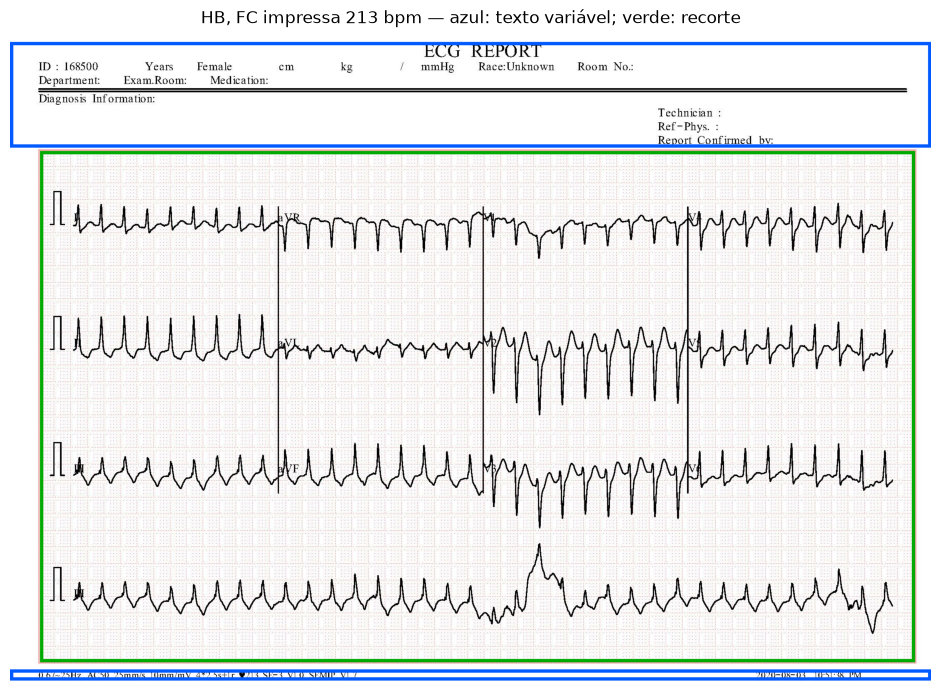

In [3]:
resumo_fc = man.groupby("categoria_original").fc_impressa.agg(
    n="size", mediana="median", minimo="min", maximo="max",
    acima_de_90=lambda s: f"{(s > 90).sum()} ({(s > 90).mean():.0%})").loc[["MI", "PMI", "HB", "Normal"]]
display(resumo_fc)
print(f"'FC impressa > 90 → anormal' identifica {((fc > 90) & (y == 1)).sum()} de {y.sum()} anormais "
      f"({((fc > 90) & (y == 1)).sum() / y.sum():.0%}) e erra {((fc > 90) & (y == 0)).sum()} normais.")
print("Sexo impresso:", dict(pd.Series(sexo).value_counts()), f"— {np.mean(sexo == 'M'):.0%} masculino")

RECORTE = (72, 287, 2173, 1514)   # interior da moldura da grade, recuado 4 px (PIL: x0, y0, x1, y1)
ex = man[man.categoria_original == "HB"].sort_values("fc_impressa").iloc[-1]
im = Image.open(EXTRAIDO / ex.representante).convert("RGB")
d = ImageDraw.Draw(im)
d.rectangle((0, 25, im.width - 1, 278), outline=(0, 90, 255), width=8)
d.rectangle((0, 1532, im.width - 1, 1558), outline=(0, 90, 255), width=8)
d.rectangle(RECORTE, outline=(0, 170, 0), width=8)
plt.figure(figsize=(12, 8.5))
plt.imshow(im); plt.axis("off")
plt.title(f"{ex.categoria_original}, FC impressa {ex.fc_impressa} bpm — azul: texto variável; verde: recorte")
plt.show()

**O recorte tira o texto, mas não o template.** Todas as imagens vêm do mesmo aparelho, do mesmo hospital, do mesmo país, com o mesmo layout: grade, rótulos das derivações, pulso de calibração e barras separadoras nos mesmos pixels. Dentro do recorte, **31% da tinta de cada imagem é template fixo** (escuro em ≥ 95% das 491 imagens). Isso é o risco de *shortcut learning* documentado na Fase 1: uma rede pode aprender a assinatura do aparelho em vez da patologia, e este dataset não tem como separar as duas coisas. O resultado deste notebook vale **para imagens deste aparelho**, não para ECG em geral.

## 5. Pré-processamento

A mesma função vale para treino, teste e exemplos:

1. **tons de cinza** (modo `L` do Pillow);
2. **recorte** `(72, 287, 2173, 1514)` → 2101×1227 px: interior da moldura recuado 4 px (a borda direita varia entre x = 2175 e 2176 por lote de digitalização; o recuo tira essa variação);
3. **redimensionamento** para **128×75** (razão 1,71 mantida) com `Image.BOX`, média de área, que transforma a linha de ~3 px do traçado em cinza em vez de apagá-la;
4. **normalização para [0, 1] e inversão** (`1 − pixel/255`): traçado ≈ 1, fundo ≈ 0.

A MLP recebe a imagem **achatada**: 128 × 75 = **9.600 entradas**. Também preparamos as duas variantes pré-declaradas: **sem recorte** (imagem inteira em 128×75, controle de H3) e **192×112** com recorte (H4).

In [4]:
def prepara(im_cinza, recorte=True, tamanho=(128, 75)):
    # im_cinza: PIL em modo L. Devolve float32 (altura, largura) em [0, 1], traçado ≈ 1.
    if recorte:
        im_cinza = im_cinza.crop(RECORTE)
    im_cinza = im_cinza.resize(tamanho, Image.BOX)
    return 1.0 - np.asarray(im_cinza, dtype=np.float32) / 255.0


VARIANTES = {  # nome: (recorte, tamanho)
    "MLP-128": (True, (128, 75)),
    "MLP-128 sem recorte": (False, (128, 75)),
    "MLP-192": (True, (192, 112)),
}
t0 = time.time()
X = {nome: np.empty((len(man), tam[1], tam[0]), np.float32) for nome, (_, tam) in VARIANTES.items()}
for i, row in enumerate(man.itertuples()):
    cinza = Image.open(EXTRAIDO / row.representante).convert("L")
    for nome, (rec, tam) in VARIANTES.items():
        X[nome][i] = prepara(cinza, rec, tam)
for nome, arr in X.items():
    print(f"{nome:20s} {arr.shape}  entradas por imagem: {arr[0].size:6d}  "
          f"faixa [{arr.min():.2f}, {arr.max():.2f}]")
print(f"({time.time() - t0:.0f} s)")

MLP-128              (491, 75, 128)  entradas por imagem:   9600  faixa [0.00, 0.85]
MLP-128 sem recorte  (491, 75, 128)  entradas por imagem:   9600  faixa [0.00, 0.76]
MLP-192              (491, 112, 192)  entradas por imagem:  21504  faixa [0.00, 0.98]
(5 s)


### 5.1 Exemplos antes/depois (entregável)

Um exemplo por categoria, salvo em [`assets/imagens/ir-alem-2/`](../../../assets/imagens/ir-alem-2/): a imagem original reduzida (`*_antes.jpg`) e **exatamente a entrada da rede** em 128×75 (`*_depois.png`, ampliada 4× por vizinho mais próximo só para ficar visível — cada quadradinho é um pixel que a MLP recebe).

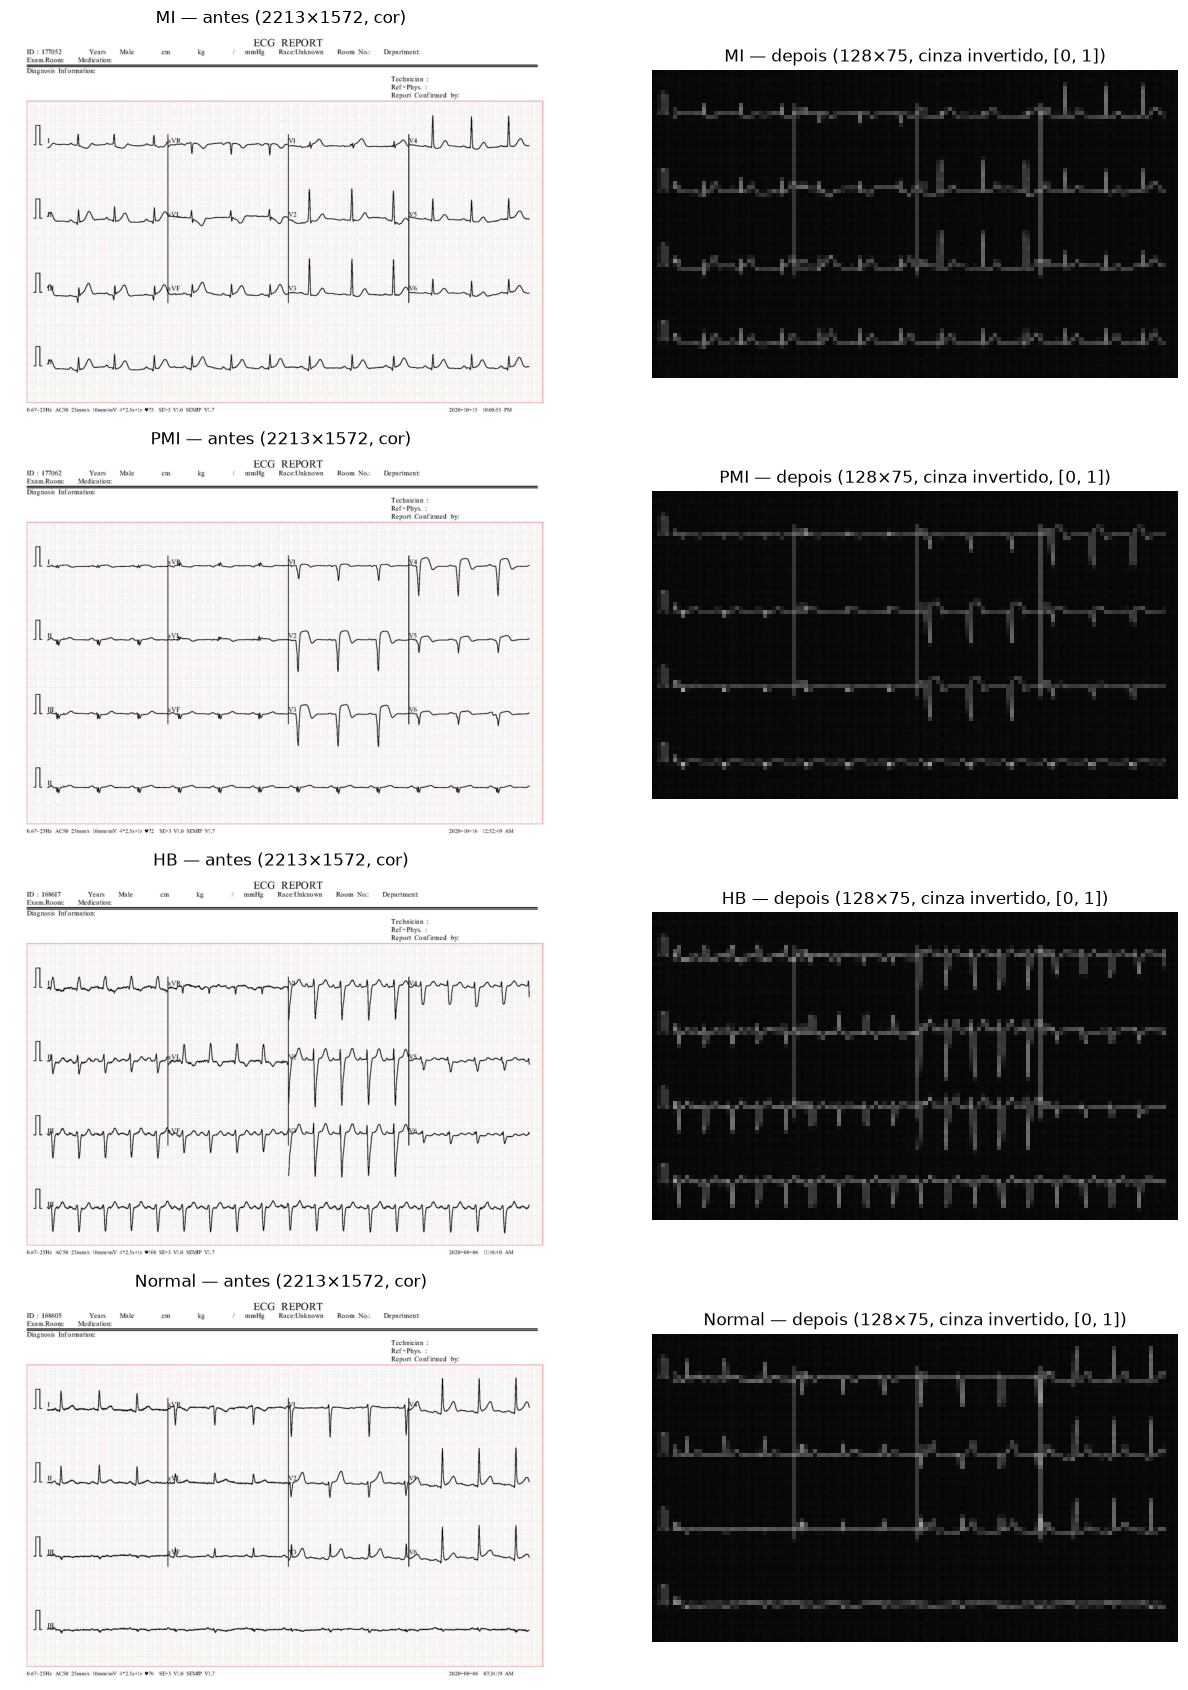

['ecg_batimento_anormal_antes.jpg', 'ecg_batimento_anormal_depois.png', 'ecg_historico_infarto_antes.jpg', 'ecg_historico_infarto_depois.png', 'ecg_infarto_antes.jpg', 'ecg_infarto_depois.png', 'ecg_normal_antes.jpg', 'ecg_normal_depois.png']


In [5]:
EXEMPLOS.mkdir(parents=True, exist_ok=True)
NOMES = {"MI": "infarto", "PMI": "historico_infarto", "HB": "batimento_anormal", "Normal": "normal"}
fig, eixos = plt.subplots(4, 2, figsize=(14, 17), gridspec_kw={"width_ratios": [1.8, 1]})
for linha, c in enumerate(["MI", "PMI", "HB", "Normal"]):
    i = int(np.flatnonzero(cat == c)[0])           # primeira da categoria por MD5
    original = Image.open(EXTRAIDO / man.representante[i]).convert("RGB")
    reduzida = original.resize((900, round(original.height * 900 / original.width)), Image.LANCZOS)
    reduzida.save(EXEMPLOS / f"ecg_{NOMES[c]}_antes.jpg", quality=85)
    entrada = Image.fromarray((X["MLP-128"][i] * 255).round().astype(np.uint8), "L")
    entrada.resize((128 * 4, 75 * 4), Image.NEAREST).save(EXEMPLOS / f"ecg_{NOMES[c]}_depois.png")
    eixos[linha, 0].imshow(reduzida); eixos[linha, 0].set_title(f"{c} — antes (2213×1572, cor)")
    eixos[linha, 1].imshow(X["MLP-128"][i], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    eixos[linha, 1].set_title(f"{c} — depois (128×75, cinza invertido, [0, 1])")
    for e in eixos[linha]:
        e.axis("off")
plt.tight_layout(); plt.show()
print(sorted(p.name for p in EXEMPLOS.iterdir()))

## 6. Split fixo (para matriz de confusão e vídeo)

Sobre as 491 **imagens únicas**, ordenadas por MD5, estratificado pela **categoria original** (para as 30 de infarto não caírem todas de um lado), semente 42: **teste 20%**; do restante, **validação 15%** (usada só pela parada antecipada) e **treino**. O teste é usado uma vez por modelo.

In [6]:
idx = np.arange(len(man))
idx_resto, idx_te = train_test_split(idx, test_size=0.20, stratify=cat, random_state=SEMENTE)
idx_tr, idx_va = train_test_split(idx_resto, test_size=0.15, stratify=cat[idx_resto], random_state=SEMENTE)
md5 = man.md5.to_numpy()
assert not (set(md5[idx_tr]) & set(md5[idx_va]) or set(md5[idx_tr]) & set(md5[idx_te]) or set(md5[idx_va]) & set(md5[idx_te]))
print("Nenhum MD5 em mais de uma parte.\n")
partes = pd.DataFrame({"parte": np.select([np.isin(idx, idx_tr), np.isin(idx, idx_va)], ["treino", "validação"], "teste"),
                       "categoria": cat, "binario": man.rotulo_binario})
display(pd.crosstab(partes.parte, [partes.binario, partes.categoria], margins=True, margins_name="total")
        .loc[["treino", "validação", "teste", "total"]])

Nenhum MD5 em mais de uma parte.



binario   anormal         normal total
categoria      HB  MI PMI Normal      
parte                                 
treino        158  20  59     96   333
validação      28   4  10     17    59
teste          47   6  17     29    99
total         233  30  86    142   491

## 7. Métricas e baselines

- **(a) classe majoritária** — sempre `anormal`;
- **(b) atalho do texto impresso** — `anormal` se a FC impressa for > 90 bpm. Não treina nada; o limiar 90 veio da leitura das 491 imagens (antes do protocolo), então este baseline é **otimista**.

Toda métrica é calculada com `anormal` = 1. O recall por subcategoria é o recall de `anormal` dentro de MI, PMI e HB.

In [7]:
def metricas(y_real, y_pred, cats):
    m = {"acurácia": accuracy_score(y_real, y_pred),
         "acurácia balanceada": balanced_accuracy_score(y_real, y_pred),
         "recall anormal": recall_score(y_real, y_pred, pos_label=1, zero_division=0),
         "recall normal": recall_score(y_real, y_pred, pos_label=0, zero_division=0)}
    for s in ["MI", "PMI", "HB"]:
        m[f"recall {s}"] = y_pred[cats == s].mean()
    return m


def baseline_majoritario(ids):
    return np.ones(len(ids), int)


def baseline_regra_fc(ids):
    return (fc[ids] > 90).astype(int)


resultados_fixo, predicoes_fixo = {}, {}
for nome, f in [("(a) majoritário", baseline_majoritario), ("(b) regra FC > 90", baseline_regra_fc)]:
    predicoes_fixo[nome] = f(idx_te)
    resultados_fixo[nome] = metricas(y[idx_te], predicoes_fixo[nome], cat[idx_te])
pd.DataFrame(resultados_fixo).T.round(3)

,acurácia,acurácia balanceada,recall anormal,recall normal,recall MI,recall PMI,recall HB
(a) majoritário,0.707,0.500,1.000,0.0,1.0,1.000,1.000
(b) regra FC > 90,0.778,0.843,0.686,1.0,0.0,0.235,0.936


## 8. MLP em Keras

A mesma arquitetura em todas as variantes. **Dropout** e **parada antecipada** são obrigatórios: a primeira camada tem 1,23 milhão de parâmetros para 333 imagens de treino. O desbalanceamento (29% normal) é tratado com **`class_weight` balanceado**, calculado no treino de cada divisão — **sem sobreamostragem**, que duplicaria imagens, exatamente o que a deduplicação removeu. Limiar de decisão fixo em 0,5.

In [8]:
def cria_mlp(forma):
    keras.utils.set_random_seed(SEMENTE)
    modelo = keras.Sequential([
        keras.Input(shape=forma),
        layers.Flatten(),                        # a imagem vira um vetor: a MLP não vê vizinhança
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),   # probabilidade de 'anormal'
    ])
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                   loss="binary_crossentropy", metrics=["accuracy"])
    return modelo


def pesos_de_classe(y_treino):
    n = len(y_treino)
    return {k: n / (2 * np.sum(y_treino == k)) for k in (0, 1)}


def treina_e_prediz(Xv, i_tr, i_va, i_te):
    modelo = cria_mlp(Xv.shape[1:])
    parada = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
    hist = modelo.fit(Xv[i_tr], y[i_tr], validation_data=(Xv[i_va], y[i_va]), epochs=200, batch_size=32,
                      class_weight=pesos_de_classe(y[i_tr]), callbacks=[parada], verbose=0)
    prob = modelo.predict(Xv[i_te], verbose=0).ravel()
    return (prob >= 0.5).astype(int), prob, hist, modelo


cria_mlp(X["MLP-128"].shape[1:]).summary()
print("class_weight no treino do split fixo:", {k: round(v, 2) for k, v in pesos_de_classe(y[idx_tr]).items()})

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 9600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,228,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,233,089 (4.70 MB)

 Trainable params: 1,233,089 (4.70 MB)

 Non-trainable params: 0 (0.00 B)

class_weight no treino do split fixo: {0: np.float64(1.73), 1: np.float64(0.7)}


### 8.1 Treino e teste no split fixo

In [9]:
historicos = {}
for nome in VARIANTES:
    t0 = time.time()
    pred, prob, hist, _ = treina_e_prediz(X[nome], idx_tr, idx_va, idx_te)
    predicoes_fixo[nome], historicos[nome] = pred, hist
    resultados_fixo[nome] = metricas(y[idx_te], pred, cat[idx_te])
    melhor = int(np.argmin(hist.history["val_loss"])) + 1
    print(f"{nome:20s} parou na época {len(hist.history['loss']):3d} (melhor val_loss na época {melhor:3d}) "
          f"— {time.time() - t0:.0f} s")

ordem = ["(a) majoritário", "(b) regra FC > 90", "MLP-128", "MLP-128 sem recorte", "MLP-192"]
tabela_fixo = pd.DataFrame(resultados_fixo).T.loc[ordem]
print(f"\nTeste do split fixo: {len(idx_te)} imagens ({y[idx_te].sum()} anormais: "
      f"MI {np.sum(cat[idx_te] == 'MI')}, PMI {np.sum(cat[idx_te] == 'PMI')}, HB {np.sum(cat[idx_te] == 'HB')}; "
      f"{np.sum(y[idx_te] == 0)} normais)")
tabela_fixo.round(3)

E0000 00:00:1790201074.610806 1884469 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


MLP-128              parou na época  29 (melhor val_loss na época  14) — 2 s


MLP-128 sem recorte  parou na época  47 (melhor val_loss na época  32) — 3 s


E0000 00:00:1790201079.753823 1884469 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


MLP-192              parou na época  31 (melhor val_loss na época  16) — 2 s

Teste do split fixo: 99 imagens (70 anormais: MI 6, PMI 17, HB 47; 29 normais)


,acurácia,acurácia balanceada,recall anormal,recall normal,recall MI,recall PMI,recall HB
(a) majoritário,0.707,0.500,1.000,0.000,1.000,1.000,1.000
(b) regra FC > 90,0.778,0.843,0.686,1.000,0.000,0.235,0.936
MLP-128,0.879,0.844,0.929,0.759,0.833,0.824,0.979
MLP-128 sem recorte,0.929,0.920,0.943,0.897,0.833,0.882,0.979
MLP-192,0.909,0.865,0.971,0.759,1.000,0.882,1.000


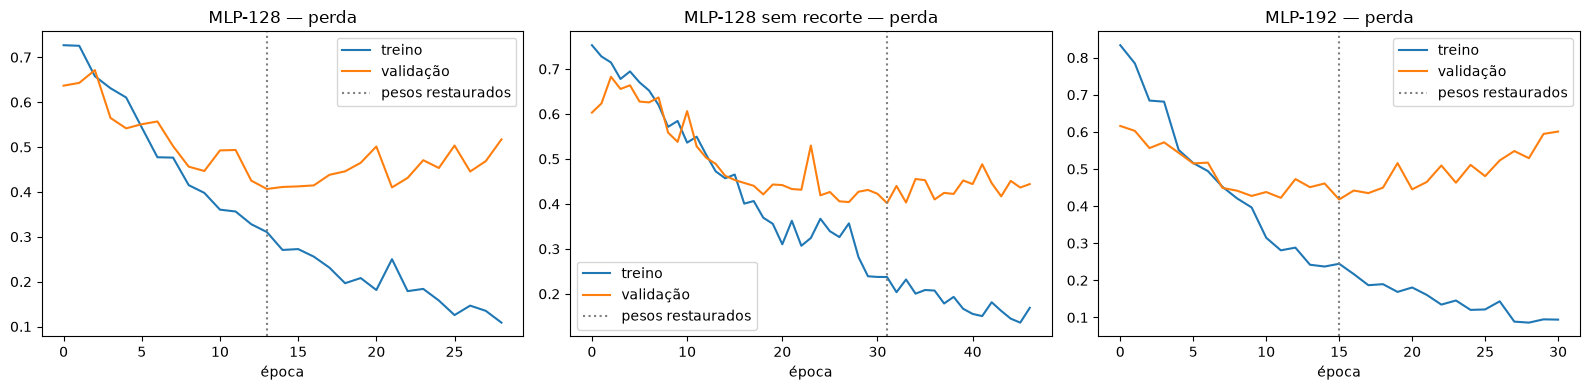

In [10]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 4))
for e, nome in zip(eixos, VARIANTES):
    h = historicos[nome].history
    e.plot(h["loss"], label="treino"); e.plot(h["val_loss"], label="validação")
    e.axvline(int(np.argmin(h["val_loss"])), color="gray", ls=":", label="pesos restaurados")
    e.set_title(f"{nome} — perda"); e.set_xlabel("época"); e.legend()
plt.tight_layout(); plt.show()

### 8.2 Matriz de confusão (split fixo)

Linhas = classe real, colunas = predição. A célula **real anormal → predito normal** é o erro perigoso.

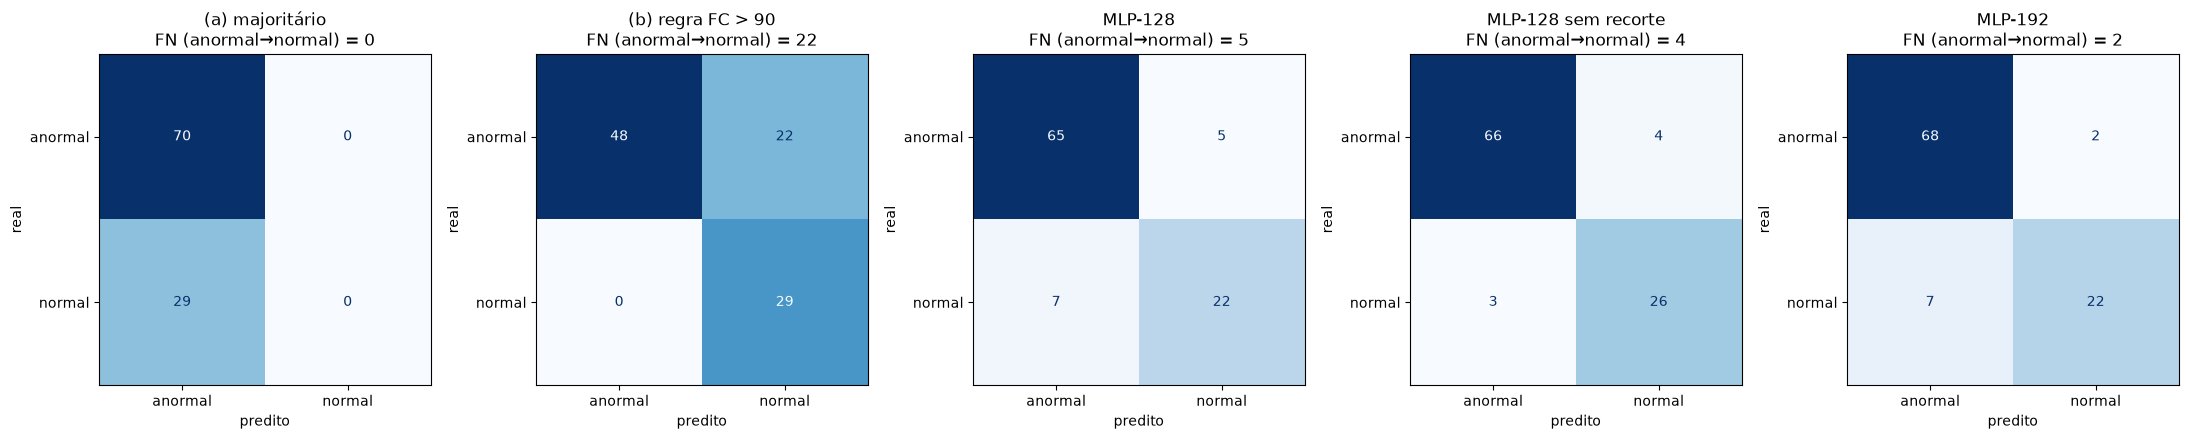

Falsos negativos da MLP-128 por subcategoria: {'PMI': np.int64(3), 'HB': np.int64(1), 'MI': np.int64(1)}


In [11]:
fig, eixos = plt.subplots(1, 5, figsize=(22, 4.2))
for e, nome in zip(eixos, ordem):
    cm = confusion_matrix(y[idx_te], predicoes_fixo[nome], labels=[1, 0])
    ConfusionMatrixDisplay(cm, display_labels=["anormal", "normal"]).plot(ax=e, colorbar=False, cmap="Blues")
    e.set_title(f"{nome}\nFN (anormal→normal) = {cm[0, 1]}")
    e.set_xlabel("predito"); e.set_ylabel("real")
plt.tight_layout(); plt.show()

fn = [i for i in idx_te if y[i] == 1 and predicoes_fixo["MLP-128"][list(idx_te).index(i)] == 0]
print("Falsos negativos da MLP-128 por subcategoria:", dict(pd.Series(cat[fn]).value_counts()))

## 9. Validação cruzada estratificada 5 × 3

O teste do split fixo tem só 99 imagens (6 de infarto): cada imagem vale 1 ponto percentual de acurácia, e o intervalo de confiança de 95% é de cerca de ±9 p.p. A validação cruzada repete a avaliação em 15 divisões e mostra quanto o número oscila. Em cada dobra, o treino é dividido de novo para a validação da parada antecipada; a dobra de teste nunca é vista. As três MLPs e os dois baselines usam **exatamente as mesmas dobras**.

In [12]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEMENTE)
modelos_cv = ["(a) majoritário", "(b) regra FC > 90", *VARIANTES]
por_dobra = []
oof = {m: np.full((3, len(man)), -1) for m in modelos_cv}   # predição fora da dobra, por repetição
t0 = time.time()
for k, (i_resto, i_te) in enumerate(cv.split(idx, cat)):
    rep = k // 5
    i_tr, i_va = train_test_split(i_resto, test_size=0.15, stratify=cat[i_resto], random_state=SEMENTE)
    assert not (set(md5[i_tr]) & set(md5[i_te]) or set(md5[i_va]) & set(md5[i_te]) or set(md5[i_tr]) & set(md5[i_va]))
    preds = {"(a) majoritário": baseline_majoritario(i_te), "(b) regra FC > 90": baseline_regra_fc(i_te)}
    for nome in VARIANTES:
        preds[nome] = treina_e_prediz(X[nome], i_tr, i_va, i_te)[0]
    for m, p in preds.items():
        oof[m][rep, i_te] = p
        por_dobra.append({"dobra": k, "repetição": rep, "modelo": m, **metricas(y[i_te], p, cat[i_te])})
    print(f"dobra {k + 1:2d}/15 — {time.time() - t0:4.0f} s")
assert all((o >= 0).all() for o in oof.values())
print("Nenhum MD5 em mais de uma parte, em nenhuma das 15 dobras.")
por_dobra = pd.DataFrame(por_dobra)

E0000 00:00:1790201086.276761 1884469 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


dobra  1/15 —    7 s


E0000 00:00:1790201091.851032 1884469 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


E0000 00:00:1790201096.960326 1884469 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


dobra  2/15 —   15 s


...

dobra 13/15 —  100 s


E0000 00:00:1790201186.680263 1884469 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


dobra 14/15 —  107 s


E0000 00:00:1790201193.940658 1884469 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


dobra 15/15 —  115 s
Nenhum MD5 em mais de uma parte, em nenhuma das 15 dobras.


In [13]:
colunas = ["acurácia", "acurácia balanceada", "recall anormal", "recall normal"]
agg = por_dobra.groupby("modelo")[colunas].agg(["mean", "std"]).loc[modelos_cv]
tabela_cv = pd.DataFrame({c: [f"{agg.loc[m, (c, 'mean')]:.3f} ± {agg.loc[m, (c, 'std')]:.3f}" for m in modelos_cv]
                          for c in colunas}, index=modelos_cv)
print("Média ± DP nas 15 dobras")
tabela_cv

Média ± DP nas 15 dobras


,acurácia,acurácia balanceada,recall anormal,recall normal
(a) majoritário,0.711 ± 0.006,0.500 ± 0.000,1.000 ± 0.000,0.000 ± 0.000
(b) regra FC > 90,0.743 ± 0.034,0.819 ± 0.024,0.639 ± 0.049,1.000 ± 0.000
MLP-128,0.831 ± 0.034,0.797 ± 0.028,0.878 ± 0.057,0.716 ± 0.061
MLP-128 sem recorte,0.822 ± 0.026,0.793 ± 0.038,0.862 ± 0.047,0.725 ± 0.098
MLP-192,0.834 ± 0.029,0.802 ± 0.044,0.880 ± 0.057,0.723 ± 0.117


### 9.1 Recall de `anormal` por subcategoria (fora da dobra)

Cada imagem é testada uma vez por repetição, então a predição fora da dobra cobre as 30 MI, 86 PMI e 233 HB. Média ± DP nas 3 repetições.

In [14]:
def recall_sub_oof(m):
    linhas = {}
    for s in ["MI", "PMI", "HB"]:
        v = [oof[m][r][cat == s].mean() for r in range(3)]
        linhas[f"{s} (n={np.sum(cat == s)})"] = f"{np.mean(v):.3f} ± {np.std(v, ddof=1):.3f}"
    return linhas


pd.DataFrame({m: recall_sub_oof(m) for m in modelos_cv}).T

,MI (n=30),PMI (n=86),HB (n=233)
(a) majoritário,1.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000
(b) regra FC > 90,0.233 ± 0.000,0.221 ± 0.000,0.845 ± 0.000
MLP-128,0.711 ± 0.051,0.822 ± 0.024,0.920 ± 0.025
MLP-128 sem recorte,0.722 ± 0.038,0.752 ± 0.036,0.920 ± 0.028
MLP-192,0.822 ± 0.019,0.748 ± 0.007,0.936 ± 0.015


## 10. Avaliação estratificada por sexo impresso

O sexo é **metadado de avaliação, não entrada** — o recorte o remove da imagem. A base é **91% masculina** (447 de 491), mais desequilibrada que a Cleveland da Fase 1 (68%). **Não há poder estatístico**: com 29 anormais femininas, um único erro muda o recall em 3,4 p.p.; no teste fixo, com 7, muda 14 p.p. Isto é **demonstração de método** — cumpre de novo o compromisso da Fase 1 de reportar métricas por subgrupo em vez de só a média global.

In [15]:
linhas = []
for m in ["(b) regra FC > 90", "MLP-128", "MLP-128 sem recorte", "MLP-192"]:
    for s in ["F", "M"]:
        for classe, rotulo in [(1, "recall anormal"), (0, "recall normal")]:
            filtro = (sexo == s) & (y == classe)
            v = [np.mean(oof[m][r][filtro] == classe) for r in range(3)]
            filtro_te = filtro[idx_te]
            fixo = np.mean(predicoes_fixo[m][filtro_te] == classe)
            linhas.append({"modelo": m, "sexo": s, "métrica": rotulo, "n (CV)": int(filtro.sum()),
                           "CV fora da dobra": f"{np.mean(v):.3f} ± {np.std(v, ddof=1):.3f}",
                           "n (teste fixo)": int(filtro_te.sum()), "teste fixo": round(fixo, 3)})
pd.DataFrame(linhas).set_index(["modelo", "métrica", "sexo"])

n (CV) CV fora da dobra  \
modelo              métrica        sexo                            
(b) regra FC > 90   recall anormal F         29    0.724 ± 0.000   
                    recall normal  F         15    1.000 ± 0.000   
                    recall anormal M        320    0.631 ± 0.000   
                    recall normal  M        127    1.000 ± 0.000   
MLP-128             recall anormal F         29    0.989 ± 0.020   
                    recall normal  F         15    0.467 ± 0.115   
                    recall anormal M        320    0.868 ± 0.028   
                    recall normal  M        127    0.745 ± 0.037   
MLP-128 sem recorte recall anormal F         29    0.839 ± 0.040   
                    recall normal  F         15    0.600 ± 0.115   
                    recall anormal M        320    0.864 ± 0.026   
                    recall normal  M        127    0.740 ± 0.071   
MLP-192             recall anormal F         29    0.920 ± 0.053   
                    recall normal  F         15    0.600 ± 0.115   
                    recall anormal M        320    0.876 ± 0.009   
                    recall normal  M        127    0.738 ± 0.048   

                                         n (teste fixo)  teste fixo  
modelo              métrica        sexo                              
(b) regra FC > 90   recall anormal F                  7       1.000  
                    recall normal  F                  2       1.000  
                    recall anormal M                 63       0.651  
                    recall normal  M                 27       1.000  
MLP-128             recall anormal F                  7       0.857  
                    recall normal  F                  2       0.500  
                    recall anormal M                 63       0.937  
                    recall normal  M                 27       0.778  
MLP-128 sem recorte recall anormal F                  7       0.714  
                    recall normal  F                  2       1.000  
                    recall anormal M                 63       0.968  
                    recall normal  M                 27       0.889  
MLP-192             recall anormal F                  7       0.857  
                    recall normal  F                  2       0.500  
                    recall anormal M                 63       0.984  
                    recall normal  M                 27       0.778

## 11. Decisão das hipóteses (calculada pelos critérios pré-registrados)

In [16]:
def pareada(a, b, metrica="acurácia balanceada"):
    pa = por_dobra[por_dobra.modelo == a].set_index("dobra")[metrica]
    pb = por_dobra[por_dobra.modelo == b].set_index("dobra")[metrica]
    d = pa - pb
    return d.mean(), d.std()


ba = por_dobra[por_dobra.modelo == "MLP-128"]["acurácia balanceada"]
h1 = "CONFIRMADA" if ba.mean() - ba.std() > 0.5 else "NÃO CONFIRMADA"

m2, s2 = pareada("MLP-128", "(b) regra FC > 90")
h2 = "MLP SUPERA a regra" if m2 - s2 > 0 else ("MLP PERDE para a regra" if m2 + s2 < 0 else "EMPATE dentro da variação")

m3, s3 = pareada("MLP-128 sem recorte", "MLP-128")
h3 = "APROVEITAMENTO DETECTADO" if m3 - s3 > 0 else "NÃO DETECTADO"

m4, s4 = pareada("MLP-192", "MLP-128")

rs = {s: [oof["MLP-128"][r][cat == s].mean() for r in range(3)] for s in ["MI", "PMI", "HB"]}
h5 = "CONFIRMADA" if all(rs["HB"][r] > rs["MI"][r] and rs["HB"][r] > rs["PMI"][r] for r in range(3)) else "NÃO CONFIRMADA"

decisoes = pd.DataFrame([
    ["H1 piso", f"BA MLP-128 = {ba.mean():.3f} ± {ba.std():.3f} (média − DP = {ba.mean() - ba.std():.3f}; piso 0,5)", h1],
    ["H2 atalho", f"BA(MLP-128) − BA(regra FC) = {m2:+.3f} ± {s2:.3f}", h2],
    ["H3 controle", f"BA(sem recorte) − BA(com recorte) = {m3:+.3f} ± {s3:.3f}", h3],
    ["H4 resolução", f"BA(MLP-192) − BA(MLP-128) = {m4:+.3f} ± {s4:.3f}", "só descrição"],
    ["H5 subcategoria", "recall por repetição — " + "; ".join(f"{s}: " + "/".join(f"{v:.2f}" for v in rs[s]) for s in rs), h5],
], columns=["hipótese", "medida", "decisão"]).set_index("hipótese")
with pd.option_context("display.max_colwidth", None):
    display(decisoes)

,medida,decisão
hipótese,,
H1 piso,"BA MLP-128 = 0.797 ± 0.028 (média − DP = 0.769; piso 0,5)",CONFIRMADA
H2 atalho,BA(MLP-128) − BA(regra FC) = -0.022 ± 0.032,EMPATE dentro da variação
H3 controle,BA(sem recorte) − BA(com recorte) = -0.004 ± 0.031,NÃO DETECTADO
H4 resolução,BA(MLP-192) − BA(MLP-128) = +0.005 ± 0.049,só descrição
H5 subcategoria,recall por repetição — MI: 0.70/0.77/0.67; PMI: 0.80/0.85/0.81; HB: 0.91/0.95/0.91,CONFIRMADA


## 12. Conclusões

> Texto escrito **depois** da execução, sem reexecutar nada (protocolo, seção 3). O que não é leitura direta de critério pré-registrado está marcado como **interpretação pós-execução**. **Registro de execuções:** a execução 1 (2026-09-23, 19:00) rodou com a variável de ambiente `MPLBACKEND=Agg`, erro de configuração que anulou o backend inline do Jupyter e deixou o notebook **sem nenhuma figura**. O código não mudou; a execução 2 (19:04), sem essa variável, é a que está salva. **Todas as métricas, tabelas e decisões saíram idênticas nas duas** (só diferem tempos e endereços de memória em avisos do TensorFlow) — o determinismo da seção 1 funcionou.

**1. A MLP aprende algo do traçado (H1 confirmada).** Na validação cruzada, a MLP-128 com recorte tem **acurácia 0,831 ± 0,034** contra o piso de 0,711 do chute majoritário, e **acurácia balanceada 0,797 ± 0,028** contra 0,5. **Recall de anormal (métrica principal): 0,878 ± 0,057** — cerca de 1 em cada 8 ECGs anormais sai como normal. No split fixo: acurácia 0,879, acurácia balanceada 0,844, recall de anormal **0,929 (65 de 70; 5 falsos negativos: 3 PMI, 1 HB, 1 MI)**, recall de normal 0,759.

**2. H2 — leitura pré-registrada: a MLP não superou a regra do texto impresso na acurácia balanceada.** MLP-128: 0,797 ± 0,028; regra "FC impressa > 90 → anormal": 0,819 ± 0,024; diferença pareada −0,022 ± 0,032 → **empate**. Pela leitura registrada no protocolo, **a rede extraiu do traçado menos do que uma linha de código lendo o número do rodapé.** A regra ainda é otimista: o limiar 90 foi visto nas 491 imagens.

> **Interpretação pós-execução (não pré-registrada).** A acurácia balanceada pesa falso negativo e falso positivo **igualmente**; a clínica não. A regra do texto impresso nunca erra um normal, mas **perde 36% dos anormais** (recall 0,639) e **pega só 0,23 dos infartos** — a MLP pega 0,71. Na métrica principal pré-registrada, **recall de anormal, a MLP é muito superior (0,878 × 0,639)**. Uma regra que perde três de cada quatro infartos não serve para triagem.

**3. Split único engana (H3: não detectado).** No split fixo, a versão **sem recorte parecia muito melhor**: 0,920 contra 0,844 de acurácia balanceada. Na validação cruzada, a diferença **some**: −0,004 ± 0,031. Com um split único, a conclusão seria a errada — "a rede lê o rodapé". São 99 imagens de teste; a variação de um sorteio para outro é maior que o efeito.

**Limite do controle.** Em 128×75 os dígitos da FC têm **menos de 1 px** de altura e não são legíveis. O resultado mostra que **o atalho não é acessível nesta resolução — não que a rede seja robusta a ele.** Em resolução maior (Fase 4, redes convolucionais), o recorte volta a ser **obrigatório**.

**4. Resolução maior não mudou nada (H4).** MLP-192: acurácia balanceada 0,802 ± 0,044, diferença pareada +0,005 ± 0,049. Com o dobro de entradas, a MLP não extraiu mais.

**5. O erro se concentra onde é mais caro (H5 confirmada).** Recall de anormal por subcategoria (fora da dobra): **HB 0,920 > PMI 0,822 > MI 0,711**. O batimento anormal, que aparece como ritmo, é o mais fácil. O **infarto agudo**, que exige morfologia fina (segmento ST, onda Q) borrada em 128×75, é o mais difícil: **cerca de 3 em cada 10 infartos saem como normal**.

**6. Sexo — hipótese, não conclusão.** Nas mulheres, o recall de anormal é **0,989**, mas o de normal é **0,467**: **metade dos ECGs normais femininos sai como anormal**. É um erro no sentido **oposto** ao risco que a Parte 2 investigou (lá, a subdetecção — falso negativo — em apresentações atípicas, mais comuns em mulheres, como o infarto sem dor). *Hipótese:* com **15 normais femininos em 491 imagens**, o que a rede aprendeu como "normal" pode ser o **normal masculino**, e um ECG normal de mulher, que difere dele, cai do lado "anormal". **n = 15 não sustenta afirmação**: cada exame vale 6,7 p.p. de recall. Fica registrado como pergunta para uma base com mais mulheres.

**7. Síntese (interpretação pós-execução): o modelo erra mais onde há menos dado.** O pior recall de anormal está no **infarto, com 30 imagens únicas (0,711)**; o pior recall de normal está nas **mulheres, com 44 imagens (0,467)**. É o mesmo padrão já registrado neste projeto: a base Cleveland da Fase 1 é 68% masculina, e a declaração científica da American Heart Association referenciada na Fase 2 (Mehta et al., 2016, *Circulation* 133(9):916–947, DOI `10.1161/CIR.0000000000000351`, seção *Prognostic Factors*, em paráfrase) aponta que os escores de risco para síndrome coronariana aguda foram desenvolvidos em populações pelo menos dois terços masculinas, com desempenho em mulheres não bem estabelecido. **Esta base é 91% masculina.**

**8. Validade.** Tudo isto vale para ECGs de um aparelho (EDAN SERIES-3), de um hospital, de um país, com 31% da tinta de cada imagem igual em todas. O sobreajuste é visível nas curvas: a perda de validação sobe a partir da época ~15, e a parada antecipada restaura os pesos dessa época. Com 1,2 milhão de parâmetros e 333 imagens de treino, este é um exercício de método, não um classificador de ECG.

**9. Gancho para a Fase 4.** A MLP **achata** a imagem e perde a **vizinhança entre pixels** — e é na forma da onda que está a morfologia do infarto, a categoria em que ela mais erra. Redes convolucionais são o passo seguinte (seção 13).

## 13. Limitações e gancho para a Fase 4

- **Um aparelho, um hospital, um país.** O resultado vale para imagens do EDAN SERIES-3 de Multan; nada aqui mostra generalização para outro equipamento ou população (*shortcut learning*, seção 4).
- **n pequeno.** 491 imagens únicas, 99 no teste fixo, 6 de infarto no teste. A validação cruzada mostra a variação, mas não cria dado novo.
- **Rótulo por pasta.** O rótulo é a pasta de origem definida pelos autores do dataset; não houve revisão de cardiologista neste projeto.
- **Resultados podem diferir levemente entre CPU local e GPU do Colab** (ponto flutuante não é bit a bit igual entre hardwares, e a parada antecipada pode parar em outra época). A referência é a execução local registrada.

**Gancho para a Fase 4 — por que uma CNN.** A MLP recebe a imagem **achatada**: os pixels (10, 20) e (10, 21) são duas entradas sem relação para a primeira camada, que teria de aprender do zero, com 333 exemplos, que pixels vizinhos formam uma linha. Ela perde a **vizinhança entre pixels** — e é na forma da onda (segmento ST, onda Q) que está a morfologia do infarto. Redes convolucionais, com filtros locais compartilhados pela imagem inteira, são o passo seguinte e o tema da **Fase 4 (Visão Computacional)**, que consome este mesmo conjunto. O risco do template do aparelho vai junto.